================================ Human Message =================================

今天北京天气怎么样？
================================== Ai Message ==================================

好的，我来查询今天北京的天气情况。
Tool Calls:
  get_weather (call_00_l6igUcVds59jDuvVVvFb8843)
 Call ID: call_00_l6igUcVds59jDuvVVvFb8843
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

今天北京的天气**不错**，是个适合出行的好天气！☀️

不过由于我查询到的信息比较简单，没有具体的温度、风力等详细数据。如果您想了解更详细的天气信息（如具体温度、湿度、降水概率等），建议您查看当地天气预报应用或网站获取更全面的数据哦！


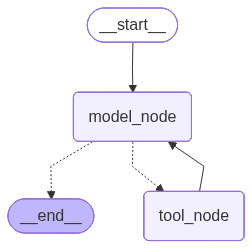

In [1]:
from typing import Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt.tool_node import ToolNode

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langchain.tools import tool

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    根据城市查询当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气不错"

tools = [get_weather]
model_with_tools = model.bind_tools(tools=tools)

def model_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = model_with_tools.invoke(input=messages)

    return {
        "messages": [response]
    }

def router(state: MessagesState) -> Literal["tool_node", END]:
    last_msg = state["messages"][-1]

    if last_msg.tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("model_node", model_node)
builder.add_node("tool_node", ToolNode(tools=tools))

builder.add_edge(START, "model_node")
builder.add_conditional_edges("model_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "model_node")

graph = builder.compile()

response = graph.invoke({"messages": [HumanMessage(content="今天北京天气怎么样？")]})
for msg in response["messages"]:
    msg.pretty_print()

from IPython.display import display
display(graph)